<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Modelo de lenguaje con tokenización por caracteres

Alumno: **Brian Adriano Salamone Castro**

Docente: **Josselyn Ordoñez**

Libro seleccionado: **Edgar Allan Poe - El escarabajo de oro**


### Consigna
- Seleccionar un corpus de texto sobre el cual entrenar el modelo de lenguaje.
- Realizar el pre-procesamiento adecuado para tokenizar el corpus, estructurar el dataset y separar entre datos de entrenamiento y validación.
- Proponer arquitecturas de redes neuronales basadas en unidades recurrentes para implementar un modelo de lenguaje.
- Con el o los modelos que consideren adecuados, generar nuevas secuencias a partir de secuencias de contexto con las estrategias de greedy search y beam search determístico y estocástico. En este último caso observar el efecto de la temperatura en la generación de secuencias.


### Sugerencias
- Durante el entrenamiento, guiarse por el descenso de la perplejidad en los datos de validación para finalizar el entrenamiento. Para ello se provee un callback.
- Explorar utilizar SimpleRNN (celda de Elman), LSTM y GRU.
- rmsprop es el optimizador recomendado para la buena convergencia. No obstante se pueden explorar otros.


In [1]:
import random
import io
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from tensorflow import keras
from tensorflow.keras import layers
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, LSTM, Embedding, Dropout
from tensorflow.keras.losses import SparseCategoricalCrossentropy

### Datos
Utilizaremos como dataset un libro, "El escarabajo de oro", de Edgar Allan Poe.

In [3]:
raw_html = urllib.request.urlopen('https://www.textos.info/edgar-allan-poe/el-escarabajo-de-oro/ebook')
raw_html = raw_html.read()

# Parsear artículo, 'lxml' es el parser a utilizar
article_html = bs.BeautifulSoup(raw_html, 'lxml')

# Encontrar todos los párrafos del HTML (bajo el tag <p>)
# y tenerlos disponible como lista
article_paragraphs = article_html.find_all('p')

article_text = ''

for para in article_paragraphs:
    article_text += para.text + ' '

# pasar todo el texto a minúscula
article_text = article_text.lower()

### Tamaño de la ventana de contexto

Se realizaron algunas pruebas sobre lo que suponian distintos tamaños de contexto. Se eligió el valor 200 para la tokenización por caracteres para obtener frases enteras con más facilidad en las secuencias, esperando así maximizar el significado extraido, sin descuidar el incremento de tiempo de procesamiento.

In [114]:
# en article text se encuentra el texto de todo el libro
idx_inicio= 1557
print("Ventana de 100:",article_text[idx_inicio:idx_inicio + 100], '\n')

print("Ventana de 200:",article_text[idx_inicio:idx_inicio + 200], '\n')

print("Ventana de 300:",article_text[idx_inicio:idx_inicio + 300], '\n')


Ventana de 100: en la más intrincada espesura de aquel soto, no muy alejada de la 
extremidad oriental y más remota  

Ventana de 200: en la más intrincada espesura de aquel soto, no muy alejada de la 
extremidad oriental y más remota de la isla, había construído legrand 
una 
pequeña cabaña que habitaba en la época en que le conocí  

Ventana de 300: en la más intrincada espesura de aquel soto, no muy alejada de la 
extremidad oriental y más remota de la isla, había construído legrand 
una 
pequeña cabaña que habitaba en la época en que le conocí incidentalmente
 por primera vez. pronto este conocimiento se convirtió en amistad, 
porque el reclu 



In [135]:
# seleccionamos el tamaño de contexto
max_context_size = 200

In [136]:
# Usaremos las utilidades de procesamiento de textos y secuencias de Keras
from tensorflow.keras.utils import pad_sequences # se utilizará para padding

In [137]:
# en este caso el vocabulario es el conjunto único de caracteres que existe en todo el texto
chars_vocab = set(article_text)

In [138]:
# la longitud de vocabulario de caracteres es:
len(chars_vocab)

64

In [139]:
# Construimos los dicionarios que asignan índices a caracteres y viceversa.
# El diccionario `char2idx` servirá como tokenizador.
char2idx = {k: v for v,k in enumerate(chars_vocab)}
idx2char = {v: k for k,v in char2idx.items()}

###  Tokenizar
La tokenización es por caracteres. Por ende, el tamaño del vocabulario es muy reducido, apenas 64.

In [140]:
# tokenizamos el texto completo
tokenized_text = [char2idx[ch] for ch in article_text]

In [141]:
str(tokenized_text[:1000])

'[52, 18, 55, 54, 11, 17, 37, 52, 18, 55, 54, 11, 17, 37, 52, 18, 59, 29, 24, 59, 52, 55, 54, 1, 38, 61, 59, 52, 59, 29, 24, 26, 52, 17, 24, 17, 41, 17, 19, 54, 52, 19, 59, 52, 11, 54, 41, 62, 61, 17, 9, 19, 59, 38, 59, 52, 55, 17, 38, 59, 61, 11, 59, 52, 28, 60, 41, 17, 19, 54, 52, 11, 17, 52, 24, 17, 61, 26, 39, 24, 62, 11, 17, 33, 52, 36, 52, 17, 11, 11, 52, 60, 39, 52, 24, 55, 59, 52, 43, 61, 54, 39, 0, 33, 53, 52, 1, 62, 41, 55, 54, 29, 52, 17, 34, 54, 29, 52, 55, 17, 52, 41, 54, 39, 24, 61, 17, 40, 59, 52, 20, 39, 24, 60, 1, 17, 52, 17, 1, 60, 29, 24, 17, 19, 52, 41, 54, 39, 52, 1, 61, 33, 52, 43, 20, 11, 11, 60, 17, 1, 52, 11, 59, 0, 61, 17, 39, 19, 33, 52, 9, 28, 59, 61, 24, 59, 39, 59, 41, 20, 17, 52, 17, 52, 62, 39, 17, 52, 17, 39, 24, 60, 0, 62, 17, 52, 47, 17, 1, 60, 11, 60, 17, 52, 55, 62, 0, 54, 39, 54, 24, 59, 52, 27, 52, 55, 17, 38, 20, 17, 52, 0, 54, 25, 17, 19, 54, 52, 19, 59, 52, 47, 54, 61, 24, 62, 39, 17, 2, 52, 9, 28, 59, 61, 54, 52, 62, 39, 17, 52, 29, 59, 61, 60

### Estructura del dataset

La estructuración del modelo es **many-to-many**. Por ende, las capas que reciben secuencias deben también devolver secuencias. Separamos el dataset en entrenamiento y validación, cuidando que la validación no sea muy abultada porque la función de callback es cara en recursos.

Entrada: secuencia de tokens [$x_0$, $x_1$, ..., $x_N$]

Target: secuencia de tokens [$x_1$, $x_2$, ..., $x_{N+1}$]

De manera que la red tiene que aprender que su salida deben ser los tokens desplazados en una posición y un nuevo token predicho (el N+1).

La ventaja de estructurar el aprendizaje de esta manera es que para cada token de target se propaga una señal de gradiente por el grafo de cómputo recurrente, que es mejor que estructurar el problema como *many-to-one* en donde sólo una señal de gradiente se propaga.

In [142]:
# separaremos el dataset entre entrenamiento y validación.
# `p_val` será la proporción del corpus que se reservará para validación
# `num_val` es la cantidad de secuencias de tamaño `max_context_size` que se usará en validación
p_val = 0.1
num_val = int(np.ceil(len(tokenized_text)*p_val/max_context_size))

In [143]:
# separamos la porción de texto utilizada en entrenamiento de la de validación.
train_text = tokenized_text[:-num_val*max_context_size]
val_text = tokenized_text[-num_val*max_context_size:]

In [144]:
tokenized_sentences_val = [val_text[init*max_context_size:init*(max_context_size+1)] for init in range(num_val)]

In [145]:
tokenized_sentences_train = [train_text[init:init+max_context_size] for init in range(len(train_text)-max_context_size+1)]

In [146]:
len(tokenized_sentences_train), len(tokenized_sentences_val)

(70784, 40)

In [147]:
X = np.array(tokenized_sentences_train[:-1])
y = np.array(tokenized_sentences_train[1:])

In [148]:
X.shape, y.shape

((70783, 200), (70783, 200))

# Definiendo el modelo

In [149]:
from keras.layers import Input, TimeDistributed, CategoryEncoding, SimpleRNN, Dense, GRU
from keras.models import Model, Sequential

Callback para el cálculo de la perplejidad. La perplejidad se calcula con la siguiente fórmula:

$$PPL = \exp\left(-\frac{1}{N}\sum_{i=1}^{N} \log P(w_i | w_1, \dots, w_{i-1})\right)$$

Donde:
- $N$: cantidad de tokens en el texto
- $w_i$: el token $i$-ésimo
- $P(w_i \mid w_1, \dots, w_{i-1})$: probabilidad que asigna el modelo al token $w_i$ dado todo el contexto anterior
- $\log$: convierte productos en sumas (estabilidad numérica)
- $-\frac{1}{N}\sum$: promedio de los log-likelihood negativos = cross-entropy
- $\exp(\cdot)$: deshace el logaritmo para volver a escala de probabilidad

In [175]:
class PplCallback(keras.callbacks.Callback):

    '''
    Este callback es una solución ad-hoc para calcular al final de cada epoch de
    entrenamiento la métrica de Perplejidad sobre un conjunto de datos de validación.
    La perplejidad es una métrica cuantitativa para evaluar la calidad de la generación de secuencias.
    Además implementa la finalización del entrenamiento (Early Stopping)
    si la perplejidad no mejora después de `patience` epochs.
    '''

    def __init__(self, val_data, history_ppl,patience=5):
      # El callback lo inicializamos con secuencias de validación sobre las cuales
      # mediremos la perplejidad
      self.val_data = val_data

      self.target = []
      self.padded = []

      count = 0
      self.info = []
      self.min_score = np.inf
      self.patience_counter = 0
      self.patience = patience
      self.history_ppl = history_ppl

      # nos movemos en todas las secuencias de los datos de validación
      for seq in self.val_data:

        len_seq = len(seq)
        # armamos todas las subsecuencias
        subseq = [seq[:i] for i in range(1,len_seq)]
        self.target.extend([seq[i] for i in range(1,len_seq)])

        if len(subseq)!=0:

          self.padded.append(pad_sequences(subseq, maxlen=max_context_size, padding='pre'))

          self.info.append((count,count+len_seq))
          count += len_seq

      self.padded = np.vstack(self.padded)


    def on_epoch_end(self, epoch, logs=None):

        # en `scores` iremos guardando la perplejidad de cada secuencia
        scores = []

        predictions = self.model.predict(self.padded,verbose=0)

        # para cada secuencia de validación
        for start,end in self.info:

          # en `probs` iremos guardando las probabilidades de los términos target
          probs = [predictions[idx_seq,-1,idx_vocab] for idx_seq, idx_vocab in zip(range(start,end),self.target[start:end])]

          # calculamos la perplejidad por medio de logaritmos
          scores.append(np.exp(-np.sum(np.log(probs))/(end-start)))

        # promediamos todos los scores e imprimimos el valor promedio
        current_score = np.mean(scores)
        self.history_ppl.append(current_score)
        print(f'\n mean perplexity: {current_score} \n')

        # chequeamos si tenemos que detener el entrenamiento
        if current_score < self.min_score:
          self.min_score = current_score
          self.model.save("my_model.keras")
          print("Saved new model!")
          self.patience_counter = 0
        else:
          self.patience_counter += 1
          if self.patience_counter == self.patience:
            print("Stopping training...")
            self.model.stop_training = True



### Definir el modelo

Usamos `TimeDistributed` junto con `CategoryEncoding` para convertir el vocabulario a one-hot a lo largo de la dimensión temporal.

Se experimentó con una capa de `Embedding` para verificar el resultado y se incurría en overfitting muy rápidamente. Es evidente que la relación entre los distintos símbolos del vocabulario no es tan potente o no guardan tanto significado como para justificar el uso de embeddings.

Utilizamos los 3 diferentes tipos de celda de memoria: SimpleRNN, LSTM y GRU. Probamos con modelos iguales y con solo esa diferencia para aislar los resultados.

In [181]:
epoch_count=20
history_ppl = {}

def get_model(nombre_celda_memoria):
  model = Sequential()

  celda_memoria = {'rnn': SimpleRNN, 'lstm': LSTM, 'gru':GRU}[nombre_celda_memoria]

  model.add(Input((None,1)))
  model.add(TimeDistributed(CategoryEncoding(num_tokens=vocab_size, output_mode = "one_hot")))
  model.add(celda_memoria(256, return_sequences=True, dropout=0.2, recurrent_dropout=0.1 ))
  model.add(Dense(vocab_size, activation='softmax'))
  model.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')
  return model

In [182]:
model = get_model('rnn')
model.summary()
history_ppl_rnn = []
model.fit(X, y, batch_size=256, epochs=epoch_count,
                 callbacks=[PplCallback(tokenized_sentences_val, history_ppl_rnn)]
                 )

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_20             │ (None, None, 64)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_7 (SimpleRNN)        │ (None, None, 256)      │        82,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, None, 64)       │        16,448 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 98,624 (385.25 KB)

 Trainable params: 98,624 (385.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 2.8470
 mean perplexity: 11.007593154907227 

Saved new model!
277/277 ━━━━━━━━━━━━━━━━━━━━ 45s 109ms/step - loss: 2.5851
Epoch 2/20
275/277 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 2.3057
 mean perplexity: 11.869974136352539 

277/277 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - loss: 2.2792
Epoch 3/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 2.2093
 mean perplexity: 11.692471504211426 

277/277 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - loss: 2.1875
Epoch 4/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 2.1267
 mean perplexity: 12.45595932006836 

277/277 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - loss: 2.1085
Epoch 5/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 2.0571
 mean perplexity: 12.287064552307129 

277/277 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - loss: 2.0426
Epoch 6/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 2.0040
 mean perplexity: 11.3869047164917 

Stopping training...
277/277 ━━━━━━━━━━━━━━━━━━━━ 9s 32m

In [183]:
model = get_model('lstm')
model.summary()
history_ppl_lstm = []
hist = model.fit(X, y, batch_size=256, epochs=epoch_count,
                 callbacks=[PplCallback(tokenized_sentences_val, history_ppl_lstm)]
                 )

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_21             │ (None, None, 64)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, None, 256)      │       328,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, None, 64)       │        16,448 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 345,152 (1.32 MB)

 Trainable params: 345,152 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 0s 668ms/step - loss: 3.0522
 mean perplexity: 13.821383476257324 

Saved new model!
277/277 ━━━━━━━━━━━━━━━━━━━━ 209s 700ms/step - loss: 2.8552
Epoch 2/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 0s 720ms/step - loss: 2.4955
 mean perplexity: 11.23003101348877 

Saved new model!
277/277 ━━━━━━━━━━━━━━━━━━━━ 213s 739ms/step - loss: 2.4437
Epoch 3/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 0s 690ms/step - loss: 2.3383
 mean perplexity: 10.594666481018066 

Saved new model!
277/277 ━━━━━━━━━━━━━━━━━━━━ 196s 704ms/step - loss: 2.3152
Epoch 4/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 0s 620ms/step - loss: 2.2538
 mean perplexity: 10.208024978637695 

Saved new model!
277/277 ━━━━━━━━━━━━━━━━━━━━ 177s 639ms/step - loss: 2.2362
Epoch 5/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 0s 655ms/step - loss: 2.1877
 mean perplexity: 10.405013084411621 

277/277 ━━━━━━━━━━━━━━━━━━━━ 185s 666ms/step - loss: 2.1735
Epoch 6/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 0s 642ms/step - loss: 2.1336
 mean perplexity: 9.9585

In [184]:
model = get_model('gru')
model.summary()
history_ppl_gru = []
hist = model.fit(X, y, batch_size=256, epochs=epoch_count,
                 callbacks=[PplCallback(tokenized_sentences_val, history_ppl_gru)]
                 )

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_22             │ (None, None, 64)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, None, 256)      │       247,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, None, 64)       │        16,448 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 263,744 (1.01 MB)

 Trainable params: 263,744 (1.01 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 0s 584ms/step - loss: 2.9785
 mean perplexity: 11.562416076660156 

Saved new model!
277/277 ━━━━━━━━━━━━━━━━━━━━ 182s 617ms/step - loss: 2.6832
Epoch 2/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 0s 570ms/step - loss: 2.3648
 mean perplexity: 10.63668155670166 

Saved new model!
277/277 ━━━━━━━━━━━━━━━━━━━━ 193s 585ms/step - loss: 2.3326
Epoch 3/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 0s 561ms/step - loss: 2.2441
 mean perplexity: 10.368400573730469 

Saved new model!
277/277 ━━━━━━━━━━━━━━━━━━━━ 161s 580ms/step - loss: 2.2168
Epoch 4/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 0s 548ms/step - loss: 2.1386
 mean perplexity: 10.196871757507324 

Saved new model!
277/277 ━━━━━━━━━━━━━━━━━━━━ 156s 563ms/step - loss: 2.1141
Epoch 5/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 0s 546ms/step - loss: 2.0436
 mean perplexity: 9.75674057006836 

Saved new model!
277/277 ━━━━━━━━━━━━━━━━━━━━ 154s 557ms/step - loss: 2.0226
Epoch 6/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 0s 558ms/step - loss: 1.9592
 mean per

In [232]:
# Relleno los arrays de historia replicando el ultimo valor, porque el early
# stopping podria hacer que queden de distintos tamaños.
for e in range(epoch_count):
  if len(history_ppl_rnn) == e: history_ppl_rnn.append(min(history_ppl_rnn))
  if len(history_ppl_lstm) == e: history_ppl_lstm.append(min(history_ppl_lstm))
  if len(history_ppl_gru) == e: history_ppl_gru.append(min(history_ppl_gru))

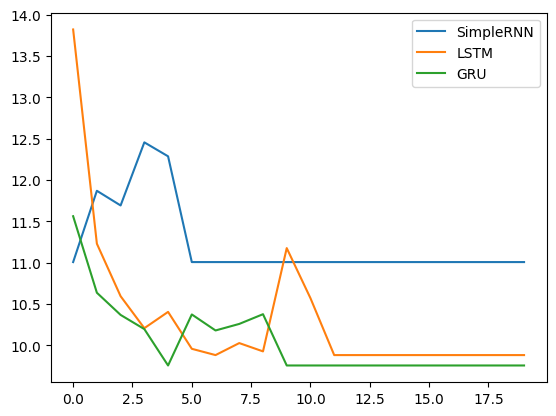

In [233]:
import matplotlib.pyplot as plt
import seaborn as sns

# Entrenamiento
sns.lineplot(x=range(epoch_count), y=history_ppl_rnn, label='SimpleRNN')
sns.lineplot(x=range(epoch_count), y=history_ppl_lstm, label='LSTM')
sns.lineplot(x=range(epoch_count), y=history_ppl_gru, label='GRU')
plt.show()

In [187]:
# Cargamos el mejor modelo guardado del entrenamiento para hacer inferencia
model = keras.models.load_model('my_model.keras')


### Predicción del próximo caracter

In [188]:
# Se puede usar gradio para probar el modelo
# Gradio es una herramienta muy útil para crear interfaces para ensayar modelos
# https://gradio.app/

!pip install -q gradio

In [59]:
import gradio as gr

def model_response(human_text):

    # Encodeamos
    encoded = [char2idx[ch] for ch in human_text.lower() ]
    # Si tienen distinto largo
    encoded = pad_sequences([encoded], maxlen=max_context_size, padding='pre')

    # Predicción softmax
    y_hat = np.argmax(model.predict(encoded)[0,-1,:])


    # Debemos buscar en el vocabulario el caracter
    # que corresopnde al indice (y_hat) predicho por le modelo
    out_word = ''
    out_word = idx2char[y_hat]

    # Agrego la palabra a la frase predicha
    return human_text + out_word

iface = gr.Interface(
    fn=model_response,
    inputs=["textbox"],
    outputs="text")

iface.launch(debug=True,share=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://25ab6b83428cb455be.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://25ab6b83428cb455be.gradio.live


### Generación de secuencias

Utilizamos esta funcion para generar las secuencias a partir del modelo y contexto pasados por parámetro.

In [189]:
def generate_seq(model, seed_text, max_length, n_words):
    """
        Exec model sequence prediction

        Args:
            model (keras): modelo entrenado
            seed_text (string): texto de entrada (input_seq)
            max_length (int): máxima longitud de la sequencia de entrada
            n_words (int): números de caracteres a agregar a la sequencia de entrada
        returns:
            output_text (string): sentencia con las "n_words" agregadas
    """
    output_text = seed_text
	# generate a fixed number of words
    for _ in range(n_words):
		# Encodeamos
        encoded = [char2idx[ch] for ch in output_text.lower() ]
		# Si tienen distinto largo
        encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')

		# Predicción softmax
        y_hat = np.argmax(model.predict(encoded,verbose=0)[0,-1,:])
		# Vamos concatenando las predicciones
        out_word = ''

        out_word = idx2char[y_hat]

		# Agrego las palabras a la frase predicha
        output_text += out_word
    return output_text

In [190]:
input_text='el escarabajo'

generate_seq(model, input_text, max_length=max_context_size, n_words=30)

'el escarabajo a la calavera de la calavera '

## Busqueda de secuencias

In [191]:
# funcionalidades para hacer encoding y decoding

def encode(text,max_length=max_context_size):

    encoded = [char2idx[ch] for ch in text]
    encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')

    return encoded

def decode(seq):
    return ''.join([idx2char[ch] for ch in seq])

### Greedy search

In [192]:
def greedy_search(modelo, texto_semilla, max_length, n_chars):
    """Genera texto eligiendo siempre el carácter más probable."""
    texto_salida = texto_semilla

    for _ in range(n_chars):
        encoded = encode(texto_salida, max_length)
        prediccion = modelo.predict(encoded, verbose=0)[0, -1, :]
        idx_predicho = np.argmax(prediccion)
        texto_salida += idx2char[idx_predicho]

    return texto_salida

In [193]:
greedy_search(model,"el escarabajo", max_context_size, 300)

'el escarabajo a la calavera de la calavera de la calavera de la calavera de la calavera de la calavera de la calavera de la calavera de la calavera de la calavera de la calavera de la calavera de la calavera de la calavera de la calavera de la calavera de la calavera de la calavera de la calavera de la calavera '

###  Beam search y muestreo aleatorio

Definimos la función que encuentra los candidatos, ya sea determinista o estocástica.

In [194]:
from scipy.special import softmax

# función que selecciona candidatos para el beam search
def select_candidates(pred,num_beams,vocab_size,history_probs,history_tokens,temp,mode):

  # colectar todas las probabilidades para la siguiente búsqueda
  pred_large = []

  for idx,pp in enumerate(pred):
    pred_large.extend(np.log(pp+1E-10)+history_probs[idx])

  pred_large = np.array(pred_large)

  # criterio de selección
  if mode == 'det':
    idx_select = np.argsort(pred_large)[::-1][:num_beams] # beam search determinista
  elif mode == 'sto':
    idx_select = np.random.choice(np.arange(pred_large.shape[0]), num_beams, p=softmax(pred_large/temp)) # beam search con muestreo aleatorio
  else:
    raise ValueError(f'Wrong selection mode. {mode} was given. det and sto are supported.')

  # traducir a índices de token en el vocabulario
  new_history_tokens = np.concatenate((np.array(history_tokens)[idx_select//vocab_size],
                        np.array([idx_select%vocab_size]).T),
                      axis=1)

  # devolver el producto de las probabilidades (log) y la secuencia de tokens seleccionados
  return pred_large[idx_select.astype(int)], new_history_tokens.astype(int)


def beam_search(model,num_beams,num_words,input,temp=1,mode='det'):

    # first iteration

    # encode
    encoded = encode(input)

    # first prediction
    y_hat = model.predict(encoded,verbose=0)[0,-1,:]

    # get vocabulary size
    vocab_size = y_hat.shape[0]

    # initialize history
    history_probs = [0]*num_beams
    history_tokens = [encoded[0]]*num_beams

    # select num_beams candidates
    history_probs, history_tokens = select_candidates([y_hat],
                                        num_beams,
                                        vocab_size,
                                        history_probs,
                                        history_tokens,
                                        temp,
                                        mode)

    # beam search loop
    for i in range(num_words-1):

      preds = []

      for hist in history_tokens:

        # actualizar secuencia de tokens
        input_update = np.array([hist[i+1:]]).copy()

        # predicción
        y_hat = model.predict(input_update,verbose=0)[0,-1,:]

        preds.append(y_hat)

      history_probs, history_tokens = select_candidates(preds,
                                                        num_beams,
                                                        vocab_size,
                                                        history_probs,
                                                        history_tokens,
                                                        temp,
                                                        mode)

    return history_tokens[:,-(len(input)+num_words):]

### Beam search determinístico

In [200]:
salidas = beam_search(model,num_beams=5,num_words=200,input="el escarabajo")

In [201]:
salidas[0]

array([59, 11, 52, 59, 29, 41, 17, 61, 17, 38, 17, 40, 54, 52, 19, 59, 52,
       11, 17, 52, 41, 17, 11, 17, 30, 59, 61, 17, 52, 19, 59, 52, 11, 17,
       52, 41, 17, 11, 17, 30, 59, 61, 17, 52, 19, 59, 52, 11, 17, 52, 41,
       17, 11, 17, 30, 59, 61, 17, 52, 19, 59, 52, 11, 17, 52, 41, 17, 11,
       17, 30, 59, 61, 17, 52, 19, 59, 52, 11, 17, 52, 41, 17, 11, 17, 30,
       59, 61, 17, 52, 19, 59, 52, 11, 17, 52, 41, 17, 11, 17, 30, 59, 61,
       17, 52, 19, 59, 52, 11, 17, 52, 41, 17, 11, 17, 30, 59, 61, 17, 52,
       19, 59, 52, 11, 17, 52, 41, 17, 11, 17, 30, 59, 61, 17, 52, 19, 59,
       52, 11, 17, 52, 41, 17, 11, 17, 30, 59, 61, 17, 52, 19, 59, 52, 11,
       17, 52, 41, 17, 11, 17, 30, 59, 61, 17, 52, 19, 59, 52, 11, 17, 52,
       41, 17, 11, 17, 30, 59, 61, 17, 52, 19, 59, 52, 11, 17, 52, 41, 17,
       11, 17, 30, 59, 61, 17, 52, 19, 59, 52, 11, 17, 52, 41, 17, 11, 17,
       30, 59, 61, 17, 52, 19, 59, 52, 11])

In [202]:
# veamos las salidas
decode(salidas[0])

'el escarabajo de la calavera de la calavera de la calavera de la calavera de la calavera de la calavera de la calavera de la calavera de la calavera de la calavera de la calavera de la calavera de la calavera de l'

### Beam search estocástico

In [203]:
salidas = beam_search(model,num_beams=5,num_words=200,input="el escarabajo", mode='sto')
for i in range(3):
  print(decode(salidas[i]), '\n')

el escarabajo de la camanara la cabaza de la calavera que 
por el para en el una de la exitar de la calavera de escarable de la calavera de la extetes de alginado de estera había 
este la esceraba al tremente en c 

el escarabajo de la camanara la cabaza de la calavera que 
por el para en el una de la exitar de la calavera de escarable de la calavera de la extetes de alginado de estera había 
este la esceraba al tremente en o 

el escarabajo de la camanara la cabaza de la calavera que 
por el para en el una de la exitar de la calavera de escarable de la calavera de la extetes de alginado de estera había 
este la esceraba al tremente en e 



### Beam search estocástico y el parámetro de la temperatura

In [234]:
temperaturas_a_intentar = [.8, 1.2, 2]
for i in temperaturas_a_intentar:
  salidas = beam_search(model,num_beams=5,num_words=100,input="el escarabajo", temp=i, mode='sto')
  print(decode(salidas[0]), '\n')


el escarabajo que la caración de la calavera de la cara en el mismo de la calavera de la calavera de la calavera  

el escarabajo que estrecida entaba lo más recestras las concidió a conserua de encente, y júpiter si pertaminas 
 

el escarabajoras predo infuenta de un compor cuentado y rinel soba el tabs 
sir de fué esta complesero, de mujesi 



## Conclusiones
Se puede ver que las celdas GRU tuvieron una performance un poco mejor, desde el punto de vista de coste computacional al entrenar, y tambien en los resultados medidos en perplejidad.

Durante el momento de la generacion de secuencias, ambos metodos deterministicos considerando el modelo que utilizaron (el gru que mejor puntaje obtuvo), arrojaron resultados muy monótonos que no fueron útiles. Esto podría deberse a que sin una optimización más detallitas (por ejemplo con mejora de los hiperparámetros y de la estructura del modelo) el modelo se enrosca en la misma frase en un bucle infinito.

El método estocástico por el contrario arroja resultados mucho más interesantes pero también incoherentes.

Podemos notar como la temperatura, a medida que sube, va resolviendo los distintos bucles infinitos que arroja el modelo, haciendo que no se atasque tan facilmente, y generando frases con más contenido, pero de la misma forma, aumenta la chance de la generación de palabras inventadas, ya que la secuencia predecida es caracter por caracter y no nos garantiza conseguir palabras que existan.